In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *


pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/chidiereoluoma/carboncataloguedataset/PublicTablesForCarbonCatalogueDataDescriptor_v30Oct2021.xlsx


# **Carbon Catalogue - Loading and Preprocessing**

In [2]:
#Loading data
df = pd.read_excel("/kaggle/input/datasets/chidiereoluoma/carboncataloguedataset/PublicTablesForCarbonCatalogueDataDescriptor_v30Oct2021.xlsx")

# Preview
df.head()

,*PCF-ID,Year of reporting,*Stage-level CO2e available,Product name (and functional unit),Product detail,Company,Country (where company is incorporated),Company's GICS Industry Group,Company's GICS Industry,*Company's sector,Product weight (kg),*Source for product weight,"Product's carbon footprint (PCF, kg CO2e)",*Carbon intensity,Protocol used for PCF,Relative change in PCF vs previous,Company-reported reason for change,*Change reason category,*%Upstream estimated from %Operations,*Upstream CO2e (fraction of total PCF),*Operations CO2e (fraction of total PCF),*Downstream CO2e (fraction of total PCF),*Transport CO2e (fraction of total PCF),*EndOfLife CO2e (fraction of total PCF),*Adjustments to raw data (if any)
0,10056-1-2014,2014,Yes,Frosted Flakes(R) Cereal,"Frosted Flakes(R), 23 oz., Produced in Lancast...",Kellogg Company,USA,"Food, Beverage & Tobacco",Food Products,Food & Beverage,0.7485,Estimated from external data based on product ...,2.00,2.67,Not reported,(not reported by company),N/a,N/a (no %change reported),No,0.575,0.3,0.125,0.045,(included in downstream but not reported separ...,Divided stage and total emissions by 1000 (bas...
1,10056-1-2015,2015,Yes,"Frosted Flakes, 23 oz, produced in Lancaster, ...",Cereal,Kellogg Company,USA,Food & Beverage Processing,Not used for 2015 reporting,Food & Beverage,0.7485,Estimated from external data based on product ...,2.00,2.67,Not reported,(not reported by company),N/a,N/a (no %change reported),No,0.575,0.3,0.125,0.045,(included in downstream but not reported separ...,Divided stage and total emissions by 1000 (bas...
2,10222-1-2013,2013,Yes,Office Chair,Field not included in 2013 data,KNOLL INC,USA,Capital Goods,Building Products,Comm. equipm. & capital goods,20.6800,Estimated from external data based on product ...,72.54,3.51,Not reported,(not reported by company),N/a,N/a (no previous data available),Yes,0.8063,0.1736,0.0201,(included in up/downstream but not reported se...,0,"Changed %change to zero, according to field ""c..."
3,10261-1-2017,2017,Yes,Multifunction Printers,bizhub C458,"Konica Minolta, Inc.",Japan,Technology Hardware & Equipment,"Electronic Equipment, Instruments & Components","Computer, IT & telecom",110.0000,Estimated from external data based on product ...,1488.00,13.53,ISO,(not reported by company),N/a,N/a (no previous data available),No,0.3065,0.0551,0.6384,0.0101,0.0276,NaN
4,10261-2-2017,2017,Yes,Multifunction Printers,bizhub C558,"Konica Minolta, Inc.",Japan,Technology Hardware & Equipment,"Electronic Equipment, Instruments & Components","Computer, IT & telecom",110.0000,Estimated from external data based on product ...,1818.00,16.53,ISO,(not reported by company),N/a,N/a (no previous data available),No,0.2508,0.0451,0.7041,0.0083,0.0226,NaN


***Initial Inspection***

In [3]:
# Structure
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 866 entries, 0 to 865
Data columns (total 25 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   *PCF-ID                                    866 non-null    object 
 1   Year of reporting                          866 non-null    int64  
 2   *Stage-level CO2e available                866 non-null    object 
 3   Product name (and functional unit)         866 non-null    object 
 4   Product detail                             856 non-null    object 
 5   Company                                    866 non-null    object 
 6   Country (where company is incorporated)    866 non-null    object 
 7   Company's GICS Industry Group              866 non-null    object 
 8   Company's GICS Industry                    866 non-null    object 
 9   *Company's sector                          866 non-null    object 
 10  Product weight (kg)       

*PCF-ID                                        0
Year of reporting                              0
*Stage-level CO2e available                    0
Product name (and functional unit)             0
Product detail                                10
Company                                        0
Country (where company is incorporated)        0
Company's GICS Industry Group                  0
Company's GICS Industry                        0
*Company's sector                              0
Product weight (kg)                            0
*Source for product weight                     0
Product's carbon footprint (PCF, kg CO2e)      0
*Carbon intensity                              0
Protocol used for PCF                          0
Relative change in PCF vs previous             0
Company-reported reason for change             0
*Change reason category                        0
*%Upstream estimated from %Operations          0
*Upstream CO2e (fraction of total PCF)         0
*Operations CO2e (fr

In [4]:
# Standardise column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("*", "", regex=False)
    .str.replace("'", "", regex=False)
    .str.replace(r"\(.*?\)", "", regex=True)  # remove anything in parentheses
    .str.strip()
    .str.replace(" ", "_")
    .str.strip("_")
)
df.columns

Index(['PCF-ID', 'Year_of_reporting', 'Stage-level_CO2e_available',
       'Product_name', 'Product_detail', 'Company', 'Country',
       'Companys_GICS_Industry_Group', 'Companys_GICS_Industry',
       'Companys_sector', 'Product_weight', 'Source_for_product_weight',
       'Products_carbon_footprint', 'Carbon_intensity',
       'Protocol_used_for_PCF', 'Relative_change_in_PCF_vs_previous',
       'Company-reported_reason_for_change', 'Change_reason_category',
       '%Upstream_estimated_from_%Operations', 'Upstream_CO2e',
       'Operations_CO2e', 'Downstream_CO2e', 'Transport_CO2e',
       'EndOfLife_CO2e', 'Adjustments_to_raw_data'],
      dtype='object')

# **Filter Sector (Food & Beverage)**

In [5]:
# Check sector values
df['Companys_sector'].value_counts()

# Filter dataset
df_food = df[df["Companys_sector"] == 'Food & Beverage']

df_food.shape

(139, 25)

**Handling Missing Values**

In [6]:
# Check missing values again
df_food = df[df["Companys_sector"] == 'Food & Beverage'].copy()
df_food.isnull().sum()

# Fill numeric columns with median
numeric_cols = df_food.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    df_food[col] = df_food[col].fillna(df_food[col].median())
    
# Fill categorical columns with mode
categorical_cols = df_food.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_food[col] = df_food[col].fillna(df_food[col].mode()[0])

In [7]:
df_food.columns

Index(['PCF-ID', 'Year_of_reporting', 'Stage-level_CO2e_available',
       'Product_name', 'Product_detail', 'Company', 'Country',
       'Companys_GICS_Industry_Group', 'Companys_GICS_Industry',
       'Companys_sector', 'Product_weight', 'Source_for_product_weight',
       'Products_carbon_footprint', 'Carbon_intensity',
       'Protocol_used_for_PCF', 'Relative_change_in_PCF_vs_previous',
       'Company-reported_reason_for_change', 'Change_reason_category',
       '%Upstream_estimated_from_%Operations', 'Upstream_CO2e',
       'Operations_CO2e', 'Downstream_CO2e', 'Transport_CO2e',
       'EndOfLife_CO2e', 'Adjustments_to_raw_data'],
      dtype='object')

**Data Type Conversion & Feature Engineering (Carbon Intensity)**

In [8]:
# Check current data types
df_food.dtypes

# Convert key columns to numeric (adjust names if needed)
df_food['Products_carbon_footprint'] = pd.to_numeric(df_food['Products_carbon_footprint'], errors='coerce')
df_food['Product_weight'] = pd.to_numeric(df_food['Product_weight'], errors='coerce')

##Feature Engineering
# Avoid division errors
df_food = df_food[df_food['Product_weight'] > 0]

# Create carbon intensity feature
df_food['Carbon_intensity'] = df_food['Products_carbon_footprint'] / df_food['Product_weight']

# Preview
df_food[['Products_carbon_footprint', 'Product_weight', 'Carbon_intensity']].head()

,Products_carbon_footprint,Product_weight,Carbon_intensity
0,2.0,0.7485,2.672011
1,2.0,0.7485,2.672011
75,650.0,1000.0000,0.650000
76,650.0,1000.0000,0.650000
77,650.0,1000.0000,0.650000


**Descriptive Statistics**

In [9]:
# Summary statistics
df_food[['Products_carbon_footprint', 'Carbon_intensity']].describe()

,Products_carbon_footprint,Carbon_intensity
count,139.000000,139.000000
mean,796.815056,5.137039
std,3854.482789,11.206474
min,0.000400,0.114800
25%,0.192000,0.500400
50%,0.885000,1.300000
75%,61.855000,2.886842
max,26836.000000,74.640000


**Product-Level Analysis (Top Emitters)**

In [10]:
# Top 10 highest emitting products
top_emitters = df_food.sort_values(by='Products_carbon_footprint', ascending=False).head(10)

top_emitters[['Company', 'Product_name', 'Products_carbon_footprint']]

,Company,Product_name,Products_carbon_footprint
552,CJ Cheiljedang,L-Arginine,26836.0
549,CJ Cheiljedang,GMP (5'-Guanylate),24839.0
550,CJ Cheiljedang,I&G (5'-Ribonucleotide),21126.0
551,CJ Cheiljedang,IMP (5'-Inosinate),18042.0
553,CJ Cheiljedang,MSG (Monosodium Glutamate),3859.0
782,NCP ALCOHOLS,Extra Neutral Potable Ethanol 96.4%,2019.0
634,Stonyfield Farm Inc,This is the average footprint of the 31 produc...,1361.0
635,Stonyfield Farm Inc,Average SKU,1360.0
783,NCP ALCOHOLS,Extra Neutral Potable Ethanol 96.4%,1280.0
787,MUNTONS PLC,Malt extract,947.0


**Company-Level Analysis**

In [11]:
company_emissions = (
    df_food.groupby('Company')['Products_carbon_footprint']
    .mean()
    .sort_values(ascending=False)
)

company_emissions.head(10)

Company
CJ Cheiljedang              15802.800000
NCP ALCOHOLS                 1649.500000
Stonyfield Farm Inc          1360.500000
Associated British Foods      650.000000
MUNTONS PLC                   578.333333
Pacific Coast Producers       187.161000
Ajinomoto Co.Inc.             143.107391
Perfection Bakeries Inc.      114.380333
Agraz                          85.057500
PURECIRCLE USA                 58.417500
Name: Products_carbon_footprint, dtype: float64

**Country-Level Analysis**

In [12]:
country_emissions = (
    df_food.groupby('Country')['Products_carbon_footprint']
    .mean()
    .sort_values(ascending=False)
)

country_emissions.head(10)

Country
South Korea       15802.800000
South Africa       1649.500000
United Kingdom      602.222222
Japan               143.107391
Spain                85.057500
USA                  75.252634
Malaysia             58.417500
Germany               5.641607
France                1.277000
Italy                 0.838500
Name: Products_carbon_footprint, dtype: float64

# **DISTRIBUTION ANALYSIS**

**HISTOGRAM (Products_carbon_footprint)**

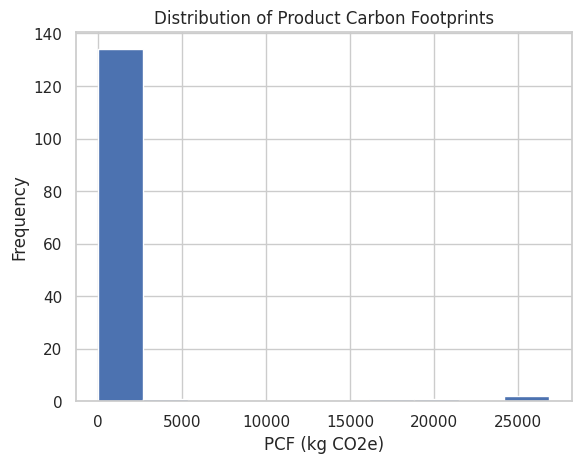

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df_food['Products_carbon_footprint'].dropna())
plt.title("Distribution of Product Carbon Footprints")
plt.xlabel("PCF (kg CO2e)")
plt.ylabel("Frequency")
plt.show()

**BOXPLOT (Carbon Intensity**

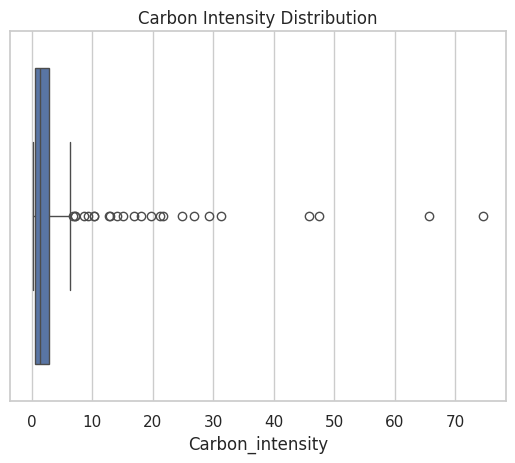

In [14]:
plt.figure()
sns.boxplot(x=df_food['Carbon_intensity'])
plt.title("Carbon Intensity Distribution")
plt.show()

**BAR CHART (Company Comparison)**

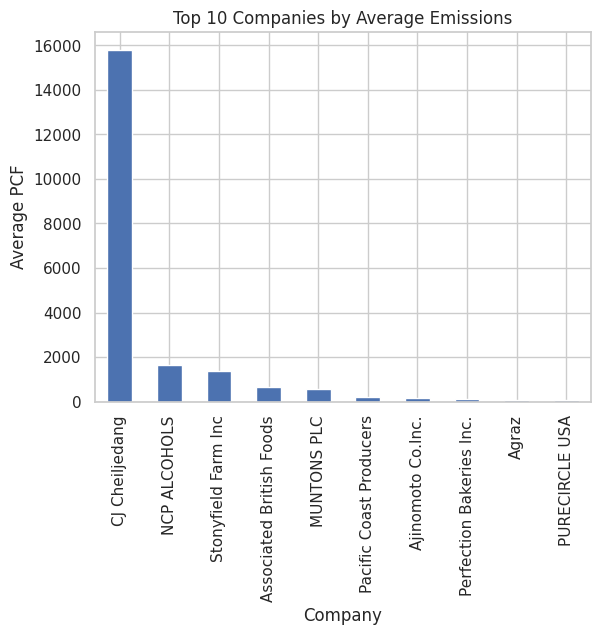

In [15]:
top_companies = company_emissions.head(10)

plt.figure()
top_companies.plot(kind='bar')
plt.title("Top 10 Companies by Average Emissions")
plt.ylabel("Average PCF")
plt.show()